In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/AffectNetCustom.zip"       # path to your zip file
extract_path = "/content/"        # where to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"📁 Extracted to: {extract_path}")


📁 Extracted to: /content/


In [ ]:
# Alternative if keras-facenet install fails
!pip install keras-facenet --quiet

# Verify it loaded correctly
from keras_facenet import FaceNet
embedder = FaceNet()
print("FaceNet loaded, output shape:", embedder.model.output_shape)
# Should print: (None, 512)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.3 MB/s eta 0:00:00
FaceNet loaded, output shape: (None, 512)


In [ ]:
import os, json, glob, math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from keras_facenet import FaceNet
from google.colab import drive

drive.mount('/content/drive')

NUM_CLASSES  = 5
IMAGE_SIZE   = 160
BATCH_SIZE   = 48  # Increased from 32 for more stable gradients
DATASET_DIR  = "/content/AffectNetCustom"
CLASS_NAMES  = sorted(["Anger", "Fear", "Happy", "Neutral", "Sad"])

DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")
CHECKPOINT_PATH = os.path.join(DRIVE_BASE, "checkpoints/fer_weights.weights.h5")
LOG_FILE        = os.path.join(DRIVE_BASE, "training_log.csv")
STATE_JSON      = os.path.join(DRIVE_BASE, "training_state.json")

os.makedirs(os.path.join(DRIVE_BASE, "best_model"),  exist_ok=True)
os.makedirs(os.path.join(DRIVE_BASE, "checkpoints"), exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# BUILD MODEL (Wider neck: 512 → 512, lighter regularization)
# ══════════════════════════════════════════════════════════════════════════════
def build_facenet_fer(num_classes=5):
    embedder = FaceNet()
    backbone = embedder.model
    backbone.trainable = False

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x      = backbone(inputs, training=False)   # (None, 512)

    # Wider neck: 512 → 512 → 128 with lighter L2 regularization
    h = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.5)(h)

    h = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.4)(h)

    # Skip connection from 512-d embedding projected to 128-d
    skip = layers.Dense(128, use_bias=False)(x)
    h = layers.Add()([h, skip])

    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)

    return models.Model(inputs, outputs, name="FaceNet_FER")

# ══════════════════════════════════════════════════════════════════════════════
# CURRICULUM LEARNING: 3 augmentation strategies with different difficulty levels
# ══════════════════════════════════════════════════════════════════════════════

def augment_light(image):
    """Phase 1: Light augmentation — flips, zooms, rotations only."""
    # Geometric
    image = tf.image.random_flip_left_right(image)
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + 20, IMAGE_SIZE + 20)
    image = tf.image.random_crop(image, [IMAGE_SIZE, IMAGE_SIZE, 3])

    # Small rotation via affine (±12°)
    angle = tf.random.uniform((), -12.0, 12.0) * (math.pi / 180.0)
    image = tf.expand_dims(image, 0)
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image,
        transforms=[[tf.cos(angle), -tf.sin(angle), 0,
                      tf.sin(angle),  tf.cos(angle), 0, 0, 0]],
        output_shape=[IMAGE_SIZE, IMAGE_SIZE],
        interpolation="BILINEAR",
        fill_mode="NEAREST",
        fill_value=0.0)
    image = tf.squeeze(image, 0)

    # Mild color jitter
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image

def augment_heavy(image):
    """Phase 2: Heavy augmentation — everything including MixUp prep."""
    # Geometric
    image = tf.image.random_flip_left_right(image)
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + 24, IMAGE_SIZE + 24)
    image = tf.image.random_crop(image, [IMAGE_SIZE, IMAGE_SIZE, 3])

    # Rotation (±15°)
    angle = tf.random.uniform((), -15.0, 15.0) * (math.pi / 180.0)
    image = tf.expand_dims(image, 0)
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image,
        transforms=[[tf.cos(angle), -tf.sin(angle), 0,
                      tf.sin(angle),  tf.cos(angle), 0, 0, 0]],
        output_shape=[IMAGE_SIZE, IMAGE_SIZE],
        interpolation="BILINEAR",
        fill_mode="NEAREST",
        fill_value=0.0)
    image = tf.squeeze(image, 0)

    # Stronger color jitter
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, 0.7, 1.3)
    image = tf.image.random_saturation(image, 0.7, 1.3)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Random grayscale (20% chance)
    if tf.random.uniform(()) > 0.8:
        image = tf.image.rgb_to_grayscale(image)
        image = tf.image.grayscale_to_rgb(image)

    # Gaussian noise (30% chance)
    if tf.random.uniform(()) > 0.7:
        noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=10.0)
        image = image + noise

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image

def augment_very_light(image):
    """Phase 3: Very light — only flip to avoid catastrophic forgetting."""
    image = tf.image.random_flip_left_right(image)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image

# ── CUTOUT augmentation ──────────────────────────────────────────────────────
def cutout(image, mask_size=40):
    """Randomly zeros out a square patch."""
    h, w = IMAGE_SIZE, IMAGE_SIZE
    cx = tf.random.uniform((), 0, w, dtype=tf.int32)
    cy = tf.random.uniform((), 0, h, dtype=tf.int32)

    x1 = tf.maximum(0, cx - mask_size // 2)
    x2 = tf.minimum(w, cx + mask_size // 2)
    y1 = tf.maximum(0, cy - mask_size // 2)
    y2 = tf.minimum(h, cy + mask_size // 2)

    mask = tf.ones([h, w, 3], dtype=image.dtype)
    padding = [[y1, h - y2], [x1, w - x2], [0, 0]]
    hole    = tf.zeros([y2 - y1, x2 - x1, 3], dtype=image.dtype)
    hole    = tf.pad(hole, padding, constant_values=1)
    mask    = mask * hole
    return image * mask

# ── MIXUP (batch-level, FIXED to ensure labels sum to 1.0) ───────────────────
def mixup(images, labels, alpha=0.1):
    """MixUp augmentation — blends pairs of images/labels in a batch (reduced alpha for less aggressive blending)."""
    batch_size = tf.shape(images)[0]

    # Sample lambda from Beta distribution
    lam = tf.random.gamma([batch_size, 1, 1, 1], alpha, beta=alpha)
    lam_labels = tf.reshape(lam, [batch_size, 1])

    # Clamp lambda to [0, 1] to ensure labels sum to 1.0
    lam = tf.clip_by_value(lam, 0.0, 1.0)
    lam_labels = tf.clip_by_value(lam_labels, 0.0, 1.0)

    indices = tf.random.shuffle(tf.range(batch_size))
    images_shuffled = tf.gather(images, indices)
    labels_shuffled = tf.gather(labels, indices)

    # Weighted blend (ensures sum = 1.0)
    mixed_images = lam * images + (1.0 - lam) * images_shuffled
    mixed_labels = lam_labels * labels + (1.0 - lam_labels) * labels_shuffled
    return mixed_images, mixed_labels

# ══════════════════════════════════════════════════════════════════════════════
# DATA PIPELINE (supports 3 augmentation modes)
# ══════════════════════════════════════════════════════════════════════════════
def process_img(path, label, aug_mode='light'):
    """
    aug_mode: 'light', 'heavy', 'very_light', or None
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, tf.float32)

    if aug_mode == 'light':
        img = augment_light(img)
    elif aug_mode == 'heavy':
        img = augment_heavy(img)
        # Apply Cutout 50% of the time in heavy mode
        if tf.random.uniform(()) > 0.5:
            img = cutout(img, mask_size=40)
    elif aug_mode == 'very_light':
        img = augment_very_light(img)
    # else: no augmentation for validation

    img = (img - 127.5) / 128.0   # FaceNet normalization
    return img, tf.one_hot(label, NUM_CLASSES)

def get_data(directory):
    paths, labels = [], []
    for idx, name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(directory, name)
        if not os.path.exists(class_dir):
            print(f"WARNING: missing {class_dir}")
            continue
        files = (glob.glob(os.path.join(class_dir, "*.jpg")) +
                 glob.glob(os.path.join(class_dir, "*.png")))
        paths.extend(files)
        labels.extend([idx] * len(files))
        print(f"  {name}: {len(files)} images (label {idx})")
    return paths, labels

def get_dataset(split, aug_mode='light', apply_mixup=False):
    """
    split: 'train' or 'val'
    aug_mode: 'light', 'heavy', 'very_light', or None
    apply_mixup: whether to apply MixUp at batch level
    """
    paths, labels = get_data(os.path.join(DATASET_DIR, split))
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    training = (split == 'train')
    if training:
        ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: process_img(p, l, aug_mode=aug_mode),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE)

    if training and apply_mixup:
        ds = ds.map(lambda imgs, lbls: mixup(imgs, lbls, alpha=0.1),
                     num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

# ── Compute class weights ─────────────────────────────────────────────────────
def compute_class_weights(directory):
    counts = []
    for name in CLASS_NAMES:
        class_dir = os.path.join(directory, name)
        n = len(glob.glob(os.path.join(class_dir, "*.jpg")) +
                glob.glob(os.path.join(class_dir, "*.png")))
        counts.append(n)
    total = sum(counts)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

class_weights = compute_class_weights(os.path.join(DATASET_DIR, "train"))

# Validation dataset (no augmentation)
print("=== VAL ===")
val_ds = get_dataset("val", aug_mode=None, apply_mixup=False)

steps_per_epoch_approx = 25000 // BATCH_SIZE

# ══════════════════════════════════════════════════════════════════════════════
# CALLBACKS (monitoring val_loss, not val_accuracy)
# ══════════════════════════════════════════════════════════════════════════════
class SaveState(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(STATE_JSON, 'w') as f:
            json.dump({'last_epoch': epoch + 1, 'phase': getattr(self, 'phase', 1)}, f)

callbacks_phase1 = [
    tf.keras.callbacks.CSVLogger(LOG_FILE, append=True),
    SaveState()
]

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, save_weights_only=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, save_best_only=True,
        monitor='val_loss', save_weights_only=True, mode='min', verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, mode='min',
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(LOG_FILE, append=True),
    SaveState()
]

callbacks_phase3 = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, save_weights_only=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, save_best_only=True,
        monitor='val_loss', save_weights_only=True, mode='min', verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, mode='min',
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.CSVLogger(LOG_FILE, append=True),
    SaveState()
]

# ══════════════════════════════════════════════════════════════════════════════
# RESUME LOGIC: Load checkpoint if training was interrupted
# ══════════════════════════════════════════════════════════════════════════════
def load_training_state():
    """Returns (last_epoch, phase) from saved state, or (0, 1) if starting fresh."""
    if os.path.exists(STATE_JSON):
        with open(STATE_JSON, 'r') as f:
            state = json.load(f)
            return state.get('last_epoch', 0), state.get('phase', 1)
    return 0, 1

resume_epoch, resume_phase = load_training_state()
print(f"\n{'='*60}")
if resume_epoch > 0:
    print(f"🔄 RESUMING from Epoch {resume_epoch}, Phase {resume_phase}")
else:
    print(f"🆕 STARTING fresh training")
print(f"{'='*60}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1: Train head only — Light augmentation (no MixUp/Cutout)
# ══════════════════════════════════════════════════════════════════════════════
if resume_phase <= 1:
    print("\n=== PHASE 1: Training head only (20 epochs, LIGHT augmentation) ===")
    print("=== TRAIN (light aug: flips, zooms, rotations) ===")
    train_ds = get_dataset("train", aug_mode='light', apply_mixup=False)

    model = build_facenet_fer(num_classes=NUM_CLASSES)

    # Resume if checkpoint exists and we're in phase 1
    if resume_epoch > 0 and resume_epoch < 20 and os.path.exists(CHECKPOINT_PATH):
        print(f"⏩ Loading checkpoint from epoch {resume_epoch}")
        model.load_weights(CHECKPOINT_PATH)

    model.compile(
        optimizer=optimizers.Adam(5e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    if resume_epoch == 0:
        model.summary()

    callbacks_phase1[1].phase = 1  # Mark current phase

    initial_epoch_p1 = min(resume_epoch, 19)
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        initial_epoch=initial_epoch_p1,
        class_weight=class_weights,
        callbacks=callbacks_phase1
    )

    resume_epoch = 20
    resume_phase = 2
else:
    # Load the model architecture
    model = build_facenet_fer(num_classes=NUM_CLASSES)

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2: Unfreeze top 180 layers — HEAVY augmentation (MixUp + Cutout)
# ══════════════════════════════════════════════════════════════════════════════
if resume_phase <= 2:
    print("\n=== PHASE 2: Fine-tuning top 180 backbone layers (50 epochs, HEAVY aug) ===")
    print("=== TRAIN (heavy aug: MixUp + Cutout + noise + strong color jitter) ===")
    train_ds = get_dataset("train", aug_mode='heavy', apply_mixup=True)

    backbone = model.layers[1]
    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers[-180:]:  # Unfreeze 180 layers (was 100) - more capacity to learn expressions
        layer.trainable = True

    # Resume if checkpoint exists and we're in phase 2
    if resume_epoch >= 20 and resume_epoch < 70 and os.path.exists(CHECKPOINT_PATH):
        print(f"⏩ Loading checkpoint from epoch {resume_epoch}")
        model.load_weights(CHECKPOINT_PATH)

    phase2_epochs = 50
    phase2_lr = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=2e-5,  # Reduced from 3e-5 for finer adjustments
        decay_steps=phase2_epochs * steps_per_epoch_approx,
        alpha=1e-7
    )

    model.compile(
        optimizer=optimizers.Adam(phase2_lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Keep 0.1
        metrics=['accuracy']
    )

    callbacks_phase2[3].phase = 2  # Mark current phase

    initial_epoch_p2 = max(20, min(resume_epoch, 69))
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=70,
        initial_epoch=initial_epoch_p2,
        class_weight=class_weights,
        callbacks=callbacks_phase2
    )

    resume_epoch = 70
    resume_phase = 3

# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3: ENABLED — Full backbone fine-tune (VERY LIGHT aug)
# ══════════════════════════════════════════════════════════════════════════════
# ⚠️  ENABLED: Full backbone fine-tuning to break past 75% accuracy plateau
RUN_PHASE_3 = True  # Full fine-tuning enabled based on confusion matrix analysis

if RUN_PHASE_3 and resume_phase <= 3:
    print("\n=== PHASE 3: Full fine-tune (30 epochs, VERY LIGHT aug) ===")
    print("=== TRAIN (very light aug: flips only) ===")
    train_ds = get_dataset("train", aug_mode='very_light', apply_mixup=False)

    for layer in backbone.layers:
        layer.trainable = True

    # Resume if checkpoint exists and we're in phase 3
    if resume_epoch >= 70 and os.path.exists(CHECKPOINT_PATH):
        print(f"⏩ Loading checkpoint from epoch {resume_epoch}")
        model.load_weights(CHECKPOINT_PATH)

    phase3_epochs = 30
    phase3_lr = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-6,
        decay_steps=phase3_epochs * steps_per_epoch_approx,
        alpha=1e-7
    )

    model.compile(
        optimizer=optimizers.Adam(phase3_lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    callbacks_phase3[3].phase = 3

    initial_epoch_p3 = max(70, min(resume_epoch, 99))
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        initial_epoch=initial_epoch_p3,
        class_weight=class_weights,
        callbacks=callbacks_phase3
    )
else:
    print(f"\n⏭️  Skipping Phase 3 (RUN_PHASE_3={RUN_PHASE_3})")
    print("   💡 If Phase 2 val_accuracy > 75%, set RUN_PHASE_3=True and re-run")

# ══════════════════════════════════════════════════════════════════════════════
# EXPORT — Full INT8 + Float16 quantized TFLite models
# ══════════════════════════════════════════════════════════════════════════════
model.load_weights(BEST_MODEL_PATH)

def representative_data_gen():
    """Yields 300 calibration samples from val set for INT8 quantization."""
    calib_dir = os.path.join(DATASET_DIR, "val")
    images = (glob.glob(os.path.join(calib_dir, "**/*.jpg"), recursive=True) +
              glob.glob(os.path.join(calib_dir, "**/*.png"), recursive=True))
    np.random.shuffle(images)
    for p in images[:300]:
        try:
            img = tf.keras.utils.load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            arr = tf.keras.utils.img_to_array(img).astype(np.float32)
            arr = (arr - 127.5) / 128.0
            yield [np.expand_dims(arr, 0)]
        except:
            pass

# ── 1) Full INT8 quantization (weights + activations) ────────────────────────
print("\n── Exporting Full INT8 TFLite model ──")
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type   = tf.int8
converter_int8.inference_output_type  = tf.int8
converter_int8._experimental_lower_tensor_list_ops = False

tflite_int8 = converter_int8.convert()

int8_path = os.path.join(DRIVE_BASE, "facenet_fer_int8.tflite")
with open(int8_path, "wb") as f:
    f.write(tflite_int8)

size_int8 = os.path.getsize(int8_path) / 1024**2
print(f"✅ INT8 model: {int8_path}  ({size_int8:.2f} MB)")

# Verify INT8 quantization
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()
tensor_details = interpreter.get_tensor_details()
float_tensors = [t for t in tensor_details if t['dtype'] == np.float32]
int8_tensors  = [t for t in tensor_details if t['dtype'] == np.int8]
print(f"   INT8 tensors: {len(int8_tensors)},  Float32 tensors: {len(float_tensors)}")
if float_tensors:
    print(f"   ⚠️  {len(float_tensors)} tensors still float32 (some ops may not support INT8)")
else:
    print(f"   ✅ All tensors quantized to INT8!")

# ── 2) Float16 quantization ───────────────────────────────────────────────────
print("\n── Exporting Float16 TFLite model ──")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_fp16.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter_fp16.convert()

fp16_path = os.path.join(DRIVE_BASE, "facenet_fer_fp16.tflite")
with open(fp16_path, "wb") as f:
    f.write(tflite_fp16)

size_fp16 = os.path.getsize(fp16_path) / 1024**2
print(f"✅ FP16 model: {fp16_path}  ({size_fp16:.2f} MB)")

# ── 3) INT8 with FP32 fallback ────────────────────────────────────────────────
print("\n── Exporting INT8 + FP32 fallback TFLite model ──")
converter_int8fb = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8fb.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_int8fb.representative_dataset = representative_data_gen
converter_int8fb.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter_int8fb.inference_input_type   = tf.int8
converter_int8fb.inference_output_type  = tf.int8

tflite_int8fb = converter_int8fb.convert()

int8fb_path = os.path.join(DRIVE_BASE, "facenet_fer_int8_fallback.tflite")
with open(int8fb_path, "wb") as f:
    f.write(tflite_int8fb)

size_int8fb = os.path.getsize(int8fb_path) / 1024**2
print(f"✅ INT8+fallback model: {int8fb_path}  ({size_int8fb:.2f} MB)")

print(f"\n{'='*60}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Summary:")
print(f"  INT8 strict:    {size_int8:.2f} MB  — smallest, fastest on INT8 HW")
print(f"  FP16:           {size_fp16:.2f} MB  — ~2x smaller than FP32, GPU friendly")
print(f"  INT8 + fallback:{size_int8fb:.2f} MB — INT8 where possible, FP32 rest")
print(f"{'='*60}")
print(f"\n📊 Training log: {LOG_FILE}")
print(f"🏆 Best weights: {BEST_MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class weights: {0: 0.9998399679935988, 1: 0.9998399679935988, 2: 1.0004403522818255, 3: 0.9998399679935988, 4: 1.0000400160064025}
=== VAL ===
  Anger: 400 images (label 0)
  Fear: 400 images (label 1)
  Happy: 400 images (label 2)
  Neutral: 400 images (label 3)
  Sad: 400 images (label 4)

🆕 STARTING fresh training


=== PHASE 1: Training head only (20 epochs, LIGHT augmentation) ===
=== TRAIN (light aug: flips, zooms, rotations) ===
  Anger: 4999 images (label 0)
  Fear: 4999 images (label 1)
  Happy: 4996 images (label 2)
  Neutral: 4999 images (label 3)
  Sad: 4998 images (label 4)


Model: "FaceNet_FER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_resnet_v1 │ (None, 512)       │ 23,497,424 │ input_layer_4[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    262,656 │ inception_resnet… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     65,664 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,536 │ inception_resnet… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_63 (Add)        │ (None, 128)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │        645 │ add_63[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,894,485 (91.15 MB)

 Trainable params: 395,781 (1.51 MB)

 Non-trainable params: 23,498,704 (89.64 MB)

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 108s 162ms/step - accuracy: 0.2965 - loss: 1.8485 - val_accuracy: 0.4125 - val_loss: 1.5147
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 106s 118ms/step - accuracy: 0.3768 - loss: 1.5943 - val_accuracy: 0.4310 - val_loss: 1.4844
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 62s 118ms/step - accuracy: 0.3955 - loss: 1.5362 - val_accuracy: 0.4260 - val_loss: 1.4782
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.4133 - loss: 1.5162 - val_accuracy: 0.4300 - val_loss: 1.4696
Epoch 5/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 61s 118ms/step - accuracy: 0.4231 - loss: 1.4950 - val_accuracy: 0.4335 - val_loss: 1.4611
Epoch 6/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 62s 118ms/step - accuracy: 0.4266 - loss: 1.4874 - val_accuracy: 0.4330 - val_loss: 1.4627
Epoch 7/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 63s 120ms/step - accuracy: 0.4264 - loss: 1.4842 - val_accuracy: 0.4350 - val_loss: 1.4548
Epoch 8/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 62s 119ms/step - accuracy: 0.4335 - loss:

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building model...
Loading best weights...
✓ Weights loaded successfully

=== VAL DATASET ===
  Anger: 705 images (label 0)
  Fear: 281 images (label 1)
  Happy: 4772 images (label 2)
  Neutral: 2524 images (label 3)
  Sad: 1982 images (label 4)

Running evaluation...
  Processed batch 0...
  Processed batch 5...
  Processed batch 10...
  Processed batch 15...
  Processed batch 20...
  Processed batch 25...
  Processed batch 30...
  Processed batch 35...
  Processed batch 40...
  Processed batch 45...
  Processed batch 50...
  Processed batch 55...
  Processed batch 60...
  Processed batch 65...
  Processed batch 70...
  Processed batch 75...
  Processed batch 80...
  Processed batch 85...
  Processed batch 90...
  Processed batch 95...
  Processed batch 100...
  Processed batch 105...
  Processed batch 110...
  Processed batch 115...
  Processed batch 120...


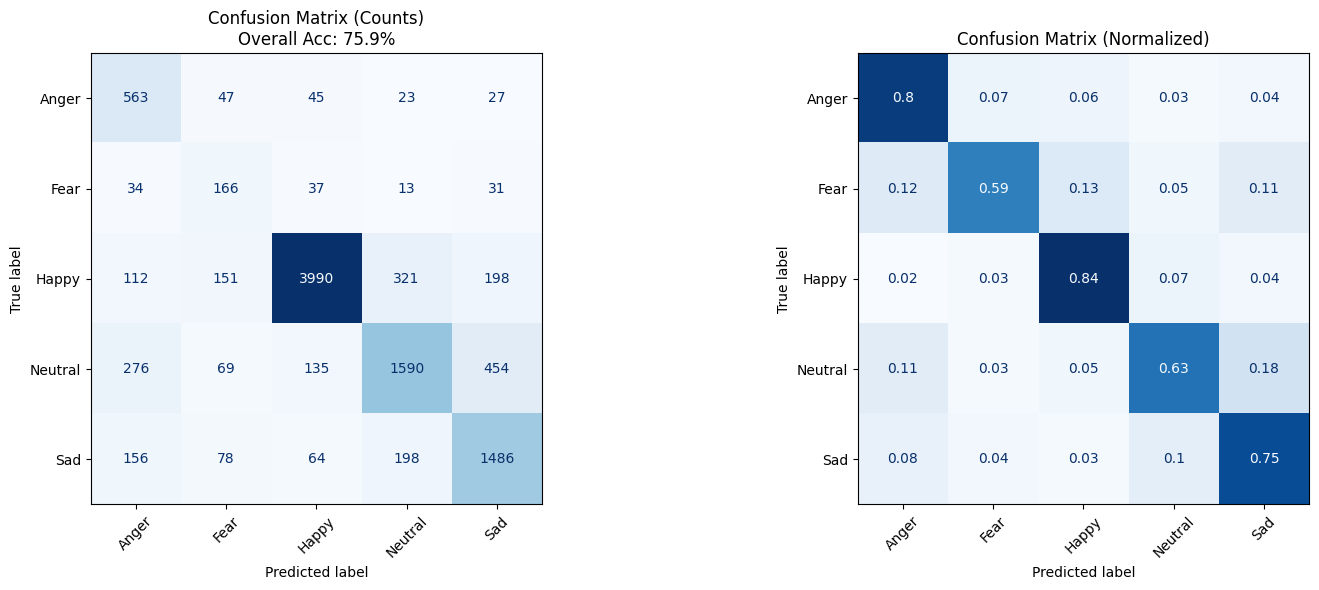

✓ Saved confusion matrix to Drive

PER-CLASS ACCURACY:
Anger   : ███████████████░░░░░  79.9%  (563/705)
Fear    : ███████████░░░░░░░░░  59.1%  (166/281)
Happy   : ████████████████░░░░  83.6%  (3990/4772)
Neutral : ████████████░░░░░░░░  63.0%  (1590/2524)
Sad     : ██████████████░░░░░░  75.0%  (1486/1982)

FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Anger       0.49      0.80      0.61       705
        Fear       0.32      0.59      0.42       281
       Happy       0.93      0.84      0.88      4772
     Neutral       0.74      0.63      0.68      2524
         Sad       0.68      0.75      0.71      1982

    accuracy                           0.76     10264
   macro avg       0.63      0.72      0.66     10264
weighted avg       0.79      0.76      0.77     10264

MOST CONFUSED PAIRS:
  Neutral  → predicted as Sad     : 454 samples
  Happy    → predicted as Neutral : 321 samples
  Neutral  → predicted as Anger   : 276 samples
  Sad      

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from keras_facenet import FaceNet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from google.colab import drive

drive.mount('/content/drive')

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
NUM_CLASSES  = 5
IMAGE_SIZE   = 160
BATCH_SIZE   = 32
DATASET_DIR  = "/content/testing rafdb"
CLASS_NAMES  = sorted(["Anger", "Fear", "Happy", "Neutral", "Sad"])

DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")

# ── REBUILD MODEL ARCHITECTURE (must match training exactly) ───────────────────
def build_facenet_fer(num_classes=5):
    embedder = FaceNet()
    backbone = embedder.model
    backbone.trainable = True  # must match final training phase

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x      = backbone(inputs, training=False)   # (None, 512)

    # Wider neck: 512 → 512 → 128 with lighter L2 regularization
    h = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.5)(h)

    h = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.4)(h)

    # Skip connection from 512-d embedding projected to 128-d
    skip = layers.Dense(128, use_bias=False)(x)
    h = layers.Add()([h, skip])

    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)

    return models.Model(inputs, outputs, name="FaceNet_FER")

print("Building model...")
model = build_facenet_fer(num_classes=NUM_CLASSES)

print("Loading best weights...")
model.load_weights(BEST_MODEL_PATH)
print("✓ Weights loaded successfully")

# ── DATA PIPELINE ─────────────────────────────────────────────────────────────
def get_data(directory):
    paths, labels = [], []
    for idx, name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(directory, name)
        if not os.path.exists(class_dir):
            print(f"WARNING: missing {class_dir}")
            continue
        files = (glob.glob(os.path.join(class_dir, "*.jpg")) +
                 glob.glob(os.path.join(class_dir, "*.png")))
        paths.extend(files)
        labels.extend([idx] * len(files))
        print(f"  {name}: {len(files)} images (label {idx})")
    return paths, labels

def process_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = (tf.cast(img, tf.float32) - 127.5) / 128.0
    return img, tf.one_hot(label, NUM_CLASSES)

def get_val_dataset():
    # Removed os.path.join(..., "val") to look directly into DATASET_DIR
    paths, labels = get_data(DATASET_DIR)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n=== VAL DATASET ===")
val_ds = get_val_dataset()

# ── EVALUATE ──────────────────────────────────────────────────────────────────
print("\nRunning evaluation...")
y_true, y_pred, y_prob = [], [], []

for batch_idx, (imgs, lbls) in enumerate(val_ds):
    preds = model(imgs, training=False)
    y_true.extend(tf.argmax(lbls,  axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
    y_prob.extend(preds.numpy())
    if batch_idx % 5 == 0:
        print(f"  Processed batch {batch_idx}...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

overall_acc = np.mean(y_true == y_pred)
print(f"\n✓ Overall Val Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (Counts)\nOverall Acc: {overall_acc*100:.1f}%')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (per-class accuracy)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp2.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "confusion_matrix.png"), dpi=150)
plt.show()
print("✓ Saved confusion matrix to Drive")

# ── PER-CLASS REPORT ──────────────────────────────────────────────────────────
print("\n" + "="*50)
print("PER-CLASS ACCURACY:")
print("="*50)
for i, name in enumerate(CLASS_NAMES):
    acc       = cm[i, i] / cm[i].sum()
    n_correct = cm[i, i]
    n_total   = cm[i].sum()
    bar       = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"{name:8s}: {bar} {acc*100:5.1f}%  ({n_correct}/{n_total})")

print("\n" + "="*50)
print("FULL CLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── MOST CONFUSED PAIRS ───────────────────────────────────────────────────────
print("MOST CONFUSED PAIRS:")
print("="*50)
confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confused.sort(reverse=True)
for count, true_cls, pred_cls in confused[:8]:
    pct = count / cm[confused[0][1:].index(true_cls) if False else
          np.where(np.array(CLASS_NAMES)==true_cls)[0][0]].sum()
    print(f"  {true_cls:8s} → predicted as {pred_cls:8s}: {count} samples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building model...
Loading best weights...
✓ Weights loaded successfully

=== VAL DATASET ===
  Anger: 2200 images (label 0)
  Fear: 2200 images (label 1)
  Happy: 2200 images (label 2)
  Neutral: 2200 images (label 3)
  Sad: 2200 images (label 4)

Running evaluation...
  Processed batch 0...
  Processed batch 5...
  Processed batch 10...
  Processed batch 15...
  Processed batch 20...
  Processed batch 25...
  Processed batch 30...
  Processed batch 35...
  Processed batch 40...
  Processed batch 45...
  Processed batch 50...
  Processed batch 55...
  Processed batch 60...
  Processed batch 65...
  Processed batch 70...
  Processed batch 75...
  Processed batch 80...
  Processed batch 85...
  Processed batch 90...
  Processed batch 95...
  Processed batch 100...
  Processed batch 105...
  Processed batch 110...
  Processed batch 115...
  Processed batch 120..

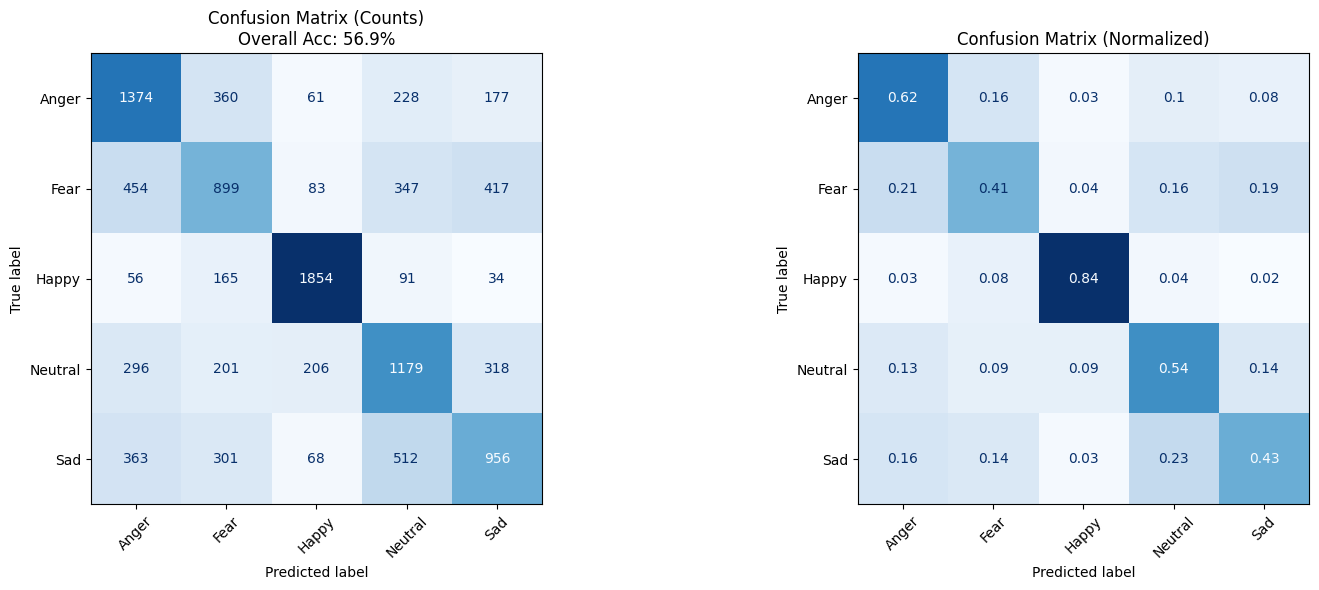

✓ Saved confusion matrix to Drive

PER-CLASS ACCURACY:
Anger   : ████████████░░░░░░░░  62.5%  (1374/2200)
Fear    : ████████░░░░░░░░░░░░  40.9%  (899/2200)
Happy   : ████████████████░░░░  84.3%  (1854/2200)
Neutral : ██████████░░░░░░░░░░  53.6%  (1179/2200)
Sad     : ████████░░░░░░░░░░░░  43.5%  (956/2200)

FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Anger       0.54      0.62      0.58      2200
        Fear       0.47      0.41      0.44      2200
       Happy       0.82      0.84      0.83      2200
     Neutral       0.50      0.54      0.52      2200
         Sad       0.50      0.43      0.47      2200

    accuracy                           0.57     11000
   macro avg       0.57      0.57      0.57     11000
weighted avg       0.57      0.57      0.57     11000

MOST CONFUSED PAIRS:
  Sad      → predicted as Neutral : 512 samples
  Fear     → predicted as Anger   : 454 samples
  Fear     → predicted as Sad     : 417 samples
  Sad    

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from keras_facenet import FaceNet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from google.colab import drive

drive.mount('/content/drive')

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
NUM_CLASSES  = 5
IMAGE_SIZE   = 160
BATCH_SIZE   = 32
DATASET_DIR  = "/content/new testing"
CLASS_NAMES  = sorted(["Anger", "Fear", "Happy", "Neutral", "Sad"])

DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")

# ── REBUILD MODEL ARCHITECTURE (must match training exactly) ───────────────────
def build_facenet_fer(num_classes=5):
    embedder = FaceNet()
    backbone = embedder.model
    backbone.trainable = True  # must match final training phase

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x      = backbone(inputs, training=False)   # (None, 512)

    # Wider neck: 512 → 512 → 128 with lighter L2 regularization
    h = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.5)(h)

    h = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.4)(h)

    # Skip connection from 512-d embedding projected to 128-d
    skip = layers.Dense(128, use_bias=False)(x)
    h = layers.Add()([h, skip])

    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)

    return models.Model(inputs, outputs, name="FaceNet_FER")

print("Building model...")
model = build_facenet_fer(num_classes=NUM_CLASSES)

print("Loading best weights...")
model.load_weights(BEST_MODEL_PATH)
print("✓ Weights loaded successfully")

# ── DATA PIPELINE ─────────────────────────────────────────────────────────────
def get_data(directory):
    paths, labels = [], []
    for idx, name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(directory, name)
        if not os.path.exists(class_dir):
            print(f"WARNING: missing {class_dir}")
            continue
        files = (glob.glob(os.path.join(class_dir, "*.jpg")) +
                 glob.glob(os.path.join(class_dir, "*.png")))
        paths.extend(files)
        labels.extend([idx] * len(files))
        print(f"  {name}: {len(files)} images (label {idx})")
    return paths, labels

def process_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = (tf.cast(img, tf.float32) - 127.5) / 128.0
    return img, tf.one_hot(label, NUM_CLASSES)

def get_val_dataset():
    # Removed os.path.join(..., "val") to look directly into DATASET_DIR
    paths, labels = get_data(DATASET_DIR)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n=== VAL DATASET ===")
val_ds = get_val_dataset()

# ── EVALUATE ──────────────────────────────────────────────────────────────────
print("\nRunning evaluation...")
y_true, y_pred, y_prob = [], [], []

for batch_idx, (imgs, lbls) in enumerate(val_ds):
    preds = model(imgs, training=False)
    y_true.extend(tf.argmax(lbls,  axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
    y_prob.extend(preds.numpy())
    if batch_idx % 5 == 0:
        print(f"  Processed batch {batch_idx}...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

overall_acc = np.mean(y_true == y_pred)
print(f"\n✓ Overall Val Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (Counts)\nOverall Acc: {overall_acc*100:.1f}%')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (per-class accuracy)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp2.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "confusion_matrix.png"), dpi=150)
plt.show()
print("✓ Saved confusion matrix to Drive")

# ── PER-CLASS REPORT ──────────────────────────────────────────────────────────
print("\n" + "="*50)
print("PER-CLASS ACCURACY:")
print("="*50)
for i, name in enumerate(CLASS_NAMES):
    acc       = cm[i, i] / cm[i].sum()
    n_correct = cm[i, i]
    n_total   = cm[i].sum()
    bar       = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"{name:8s}: {bar} {acc*100:5.1f}%  ({n_correct}/{n_total})")

print("\n" + "="*50)
print("FULL CLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── MOST CONFUSED PAIRS ───────────────────────────────────────────────────────
print("MOST CONFUSED PAIRS:")
print("="*50)
confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confused.sort(reverse=True)
for count, true_cls, pred_cls in confused[:8]:
    pct = count / cm[confused[0][1:].index(true_cls) if False else
          np.where(np.array(CLASS_NAMES)==true_cls)[0][0]].sum()
    print(f"  {true_cls:8s} → predicted as {pred_cls:8s}: {count} samples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building model...
Loading best weights...
✓ Weights loaded successfully

=== VAL DATASET ===
  Anger: 3995 images (label 0)
  Fear: 4097 images (label 1)
  Happy: 7215 images (label 2)
  Neutral: 4965 images (label 3)
  Sad: 4830 images (label 4)

Running evaluation...
  Processed batch 0...
  Processed batch 5...
  Processed batch 10...
  Processed batch 15...
  Processed batch 20...
  Processed batch 25...
  Processed batch 30...
  Processed batch 35...
  Processed batch 40...
  Processed batch 45...
  Processed batch 50...
  Processed batch 55...
  Processed batch 60...
  Processed batch 65...
  Processed batch 70...
  Processed batch 75...
  Processed batch 80...
  Processed batch 85...
  Processed batch 90...
  Processed batch 95...
  Processed batch 100...
  Processed batch 105...
  Processed batch 110...
  Processed batch 115...
  Processed batch 120..

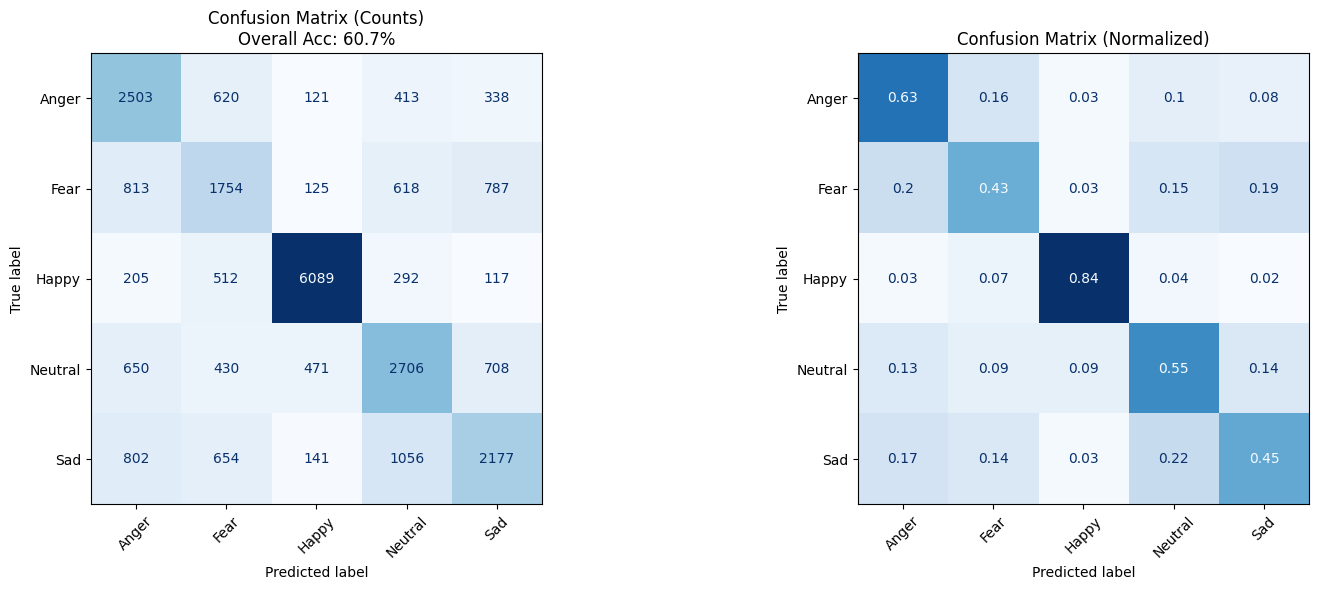

✓ Saved confusion matrix to Drive

PER-CLASS ACCURACY:
Anger   : ████████████░░░░░░░░  62.7%  (2503/3995)
Fear    : ████████░░░░░░░░░░░░  42.8%  (1754/4097)
Happy   : ████████████████░░░░  84.4%  (6089/7215)
Neutral : ██████████░░░░░░░░░░  54.5%  (2706/4965)
Sad     : █████████░░░░░░░░░░░  45.1%  (2177/4830)

FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Anger       0.50      0.63      0.56      3995
        Fear       0.44      0.43      0.43      4097
       Happy       0.88      0.84      0.86      7215
     Neutral       0.53      0.55      0.54      4965
         Sad       0.53      0.45      0.49      4830

    accuracy                           0.61     25102
   macro avg       0.58      0.58      0.58     25102
weighted avg       0.61      0.61      0.61     25102

MOST CONFUSED PAIRS:
  Sad      → predicted as Neutral : 1056 samples
  Fear     → predicted as Anger   : 813 samples
  Sad      → predicted as Anger   : 802 samples
  Fear

In [ ]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from keras_facenet import FaceNet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from google.colab import drive

drive.mount('/content/drive')

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
NUM_CLASSES  = 5
IMAGE_SIZE   = 160
BATCH_SIZE   = 32
DATASET_DIR  = "/content/train"
CLASS_NAMES  = sorted(["Anger", "Fear", "Happy", "Neutral", "Sad"])

DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")

# ── REBUILD MODEL ARCHITECTURE (must match training exactly) ───────────────────
def build_facenet_fer(num_classes=5):
    embedder = FaceNet()
    backbone = embedder.model
    backbone.trainable = True  # must match final training phase

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x      = backbone(inputs, training=False)   # (None, 512)

    # Wider neck: 512 → 512 → 128 with lighter L2 regularization
    h = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.5)(h)

    h = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
    h = layers.BatchNormalization()(h)
    h = layers.ReLU()(h)
    h = layers.Dropout(0.4)(h)

    # Skip connection from 512-d embedding projected to 128-d
    skip = layers.Dense(128, use_bias=False)(x)
    h = layers.Add()([h, skip])

    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)

    return models.Model(inputs, outputs, name="FaceNet_FER")

print("Building model...")
model = build_facenet_fer(num_classes=NUM_CLASSES)

print("Loading best weights...")
model.load_weights(BEST_MODEL_PATH)
print("✓ Weights loaded successfully")

# ── DATA PIPELINE ─────────────────────────────────────────────────────────────
def get_data(directory):
    paths, labels = [], []
    for idx, name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(directory, name)
        if not os.path.exists(class_dir):
            print(f"WARNING: missing {class_dir}")
            continue
        files = (glob.glob(os.path.join(class_dir, "*.jpg")) +
                 glob.glob(os.path.join(class_dir, "*.png")))
        paths.extend(files)
        labels.extend([idx] * len(files))
        print(f"  {name}: {len(files)} images (label {idx})")
    return paths, labels

def process_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = (tf.cast(img, tf.float32) - 127.5) / 128.0
    return img, tf.one_hot(label, NUM_CLASSES)

def get_val_dataset():
    # Removed os.path.join(..., "val") to look directly into DATASET_DIR
    paths, labels = get_data(DATASET_DIR)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(process_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n=== VAL DATASET ===")
val_ds = get_val_dataset()

# ── EVALUATE ──────────────────────────────────────────────────────────────────
print("\nRunning evaluation...")
y_true, y_pred, y_prob = [], [], []

for batch_idx, (imgs, lbls) in enumerate(val_ds):
    preds = model(imgs, training=False)
    y_true.extend(tf.argmax(lbls,  axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
    y_prob.extend(preds.numpy())
    if batch_idx % 5 == 0:
        print(f"  Processed batch {batch_idx}...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

overall_acc = np.mean(y_true == y_pred)
print(f"\n✓ Overall Val Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (Counts)\nOverall Acc: {overall_acc*100:.1f}%')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (per-class accuracy)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp2.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, "confusion_matrix.png"), dpi=150)
plt.show()
print("✓ Saved confusion matrix to Drive")

# ── PER-CLASS REPORT ──────────────────────────────────────────────────────────
print("\n" + "="*50)
print("PER-CLASS ACCURACY:")
print("="*50)
for i, name in enumerate(CLASS_NAMES):
    acc       = cm[i, i] / cm[i].sum()
    n_correct = cm[i, i]
    n_total   = cm[i].sum()
    bar       = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"{name:8s}: {bar} {acc*100:5.1f}%  ({n_correct}/{n_total})")

print("\n" + "="*50)
print("FULL CLASSIFICATION REPORT:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── MOST CONFUSED PAIRS ───────────────────────────────────────────────────────
print("MOST CONFUSED PAIRS:")
print("="*50)
confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confused.sort(reverse=True)
for count, true_cls, pred_cls in confused[:8]:
    pct = count / cm[confused[0][1:].index(true_cls) if False else
          np.where(np.array(CLASS_NAMES)==true_cls)[0][0]].sum()
    print(f"  {true_cls:8s} → predicted as {pred_cls:8s}: {count} samples")

In [ ]:
import os, glob, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model

# ── CONFIG ───────────────────────────────────────────────────────────────────
MODEL_WEIGHTS_PATH = "/content/drive/MyDrive/FaceNet_FER5/best_model/best_fer.weights.h5"
OUTPUT_DIR         = "/content/drive/MyDrive/FaceNet_FER5/quantized"
CALIB_DATA_DIR     = "/content/AffectNetCustom/val"
IMG_SIZE           = (160, 160)
NUM_CLASSES        = 5
NUM_CALIB_SAMPLES  = 200
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── BUILD MODEL ───────────────────────────────────────────────────────────────
def build_model():
    from keras_facenet import FaceNet
    base = FaceNet().model
    base.trainable = False

    inp  = tf.keras.Input(shape=(160, 160, 3))
    x    = base(inp)

    h    = layers.Dense(512, use_bias=True)(x)
    h    = layers.BatchNormalization()(h)
    h    = layers.ReLU()(h)
    h    = layers.Dropout(0.4)(h)
    h    = layers.Dense(128, use_bias=True)(h)
    h    = layers.BatchNormalization()(h)
    h    = layers.ReLU()(h)
    h    = layers.Dropout(0.4)(h)

    skip = layers.Dense(128, use_bias=False)(x)  # no bias confirmed from weights

    h    = layers.Add()([h, skip])
    out  = layers.Dense(NUM_CLASSES, activation="softmax")(h)

    return Model(inp, out, name="FaceNet_FER")

def load_model():
    print("⏳ Building model & loading weights …")
    model = build_model()
    model.load_weights(MODEL_WEIGHTS_PATH)
    model.trainable = False
    print(f"✅ Loaded. Params: {model.count_params():,}")
    return model

# ── CALIBRATION DATA ──────────────────────────────────────────────────────────
def make_calib_dataset(n=NUM_CALIB_SAMPLES):
    paths = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        paths += glob.glob(os.path.join(CALIB_DATA_DIR, "**", ext), recursive=True)
    np.random.shuffle(paths)
    paths = paths[:n]

    def _prep(p):
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = (tf.cast(img, tf.float32) - 127.5) / 128.0
        return img

    return tf.data.Dataset.from_tensor_slices(paths).map(_prep).batch(1)

def rep_data_gen():
    for sample in make_calib_dataset():
        yield [sample]

# ── QUANTIZE FP16 ─────────────────────────────────────────────────────────────
def quantize_fp16_direct(model):
    print("\n🔵 FP16 quantization …")
    c = tf.lite.TFLiteConverter.from_keras_model(model)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.target_spec.supported_types = [tf.float16]
    buf = c.convert()
    out = os.path.join(OUTPUT_DIR, "fer_fp16.tflite")
    open(out, "wb").write(buf)
    print(f"✅ FP16 → {out}  ({os.path.getsize(out)/1e6:.2f} MB)")
    return out

# ── QUANTIZE FULL INT8 ────────────────────────────────────────────────────────
def quantize_int8_direct(model):
    print("\n🟠 Full INT8 quantization …")
    c = tf.lite.TFLiteConverter.from_keras_model(model)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = rep_data_gen
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c.inference_input_type  = tf.int8
    c.inference_output_type = tf.int8
    buf = c.convert()
    out = os.path.join(OUTPUT_DIR, "fer_int8.tflite")
    open(out, "wb").write(buf)
    print(f"✅ INT8 → {out}  ({os.path.getsize(out)/1e6:.2f} MB)")
    return out

# ── SMOKE TEST ────────────────────────────────────────────────────────────────
def test_tflite(path, n=50):
    import time
    print(f"\n🧪 Testing {os.path.basename(path)} …")
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    i_det = interp.get_input_details()[0]
    o_det = interp.get_output_details()[0]
    is_int8 = i_det["dtype"] == np.int8
    times = []
    for batch in make_calib_dataset(n):
        img = batch[0].numpy()
        if is_int8:
            s, z = i_det["quantization"]
            img  = (img / s + z).astype(np.int8)
        interp.set_tensor(i_det["index"], img[np.newaxis])
        t0 = time.perf_counter()
        interp.invoke()
        times.append(time.perf_counter() - t0)
    print(f"   Avg latency: {np.mean(times)*1000:.1f} ms over {n} samples")

# ── MAIN ──────────────────────────────────────────────────────────────────────
model = load_model()
fp16  = quantize_fp16_direct(model)
int8  = quantize_int8_direct(model)
test_tflite(fp16)
test_tflite(int8)

print("\n" + "="*50)
for label, p in [("FP16", fp16), ("INT8", int8)]:
    print(f"  {label}: {os.path.getsize(p)/1e6:.2f} MB → {p}")
print("="*50)

⏳ Building model & loading weights …
✅ Loaded. Params: 23,894,485

🔵 FP16 quantization …
Saved artifact at '/tmp/tmpt2qwmy7y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_4544')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132318847086480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847089360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088976: TensorSpec(shape=(), dtype=tf.resource, nam

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8 → /content/drive/MyDrive/FaceNet_FER5/quantized/fer_int8.tflite  (24.96 MB)

🧪 Testing fer_fp16.tflite …


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   Avg latency: 61.1 ms over 50 samples

🧪 Testing fer_int8.tflite …
   Avg latency: 44.4 ms over 50 samples

  FP16: 47.86 MB → /content/drive/MyDrive/FaceNet_FER5/quantized/fer_fp16.tflite
  INT8: 24.96 MB → /content/drive/MyDrive/FaceNet_FER5/quantized/fer_int8.tflite


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from keras_facenet import FaceNet
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import drive, files

drive.mount('/content/drive')

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
NUM_CLASSES  = 5
IMAGE_SIZE   = 160
CLASS_NAMES  = sorted(["Anger", "Fear", "Happy", "Neutral", "Sad"])
EMOJI        = {"Anger": "😠", "Fear": "😨", "Happy": "😊", "Neutral": "😐", "Sad": "😢"}
COLORS       = {"Anger": "#FF4444", "Fear": "#FF8C00", "Happy": "#44BB44",
                "Neutral": "#4488FF", "Sad": "#AA44FF"}

DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")

# ── BUILD & LOAD MODEL ────────────────────────────────────────────────────────
def build_facenet_fer(num_classes=5):
    embedder = FaceNet()
    backbone = embedder.model
    backbone.trainable = True
    inputs  = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x       = backbone(inputs, training=False)
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name="FaceNet_FER")

print("Loading model...")
model = build_facenet_fer()
model.load_weights(BEST_MODEL_PATH)
print("✓ Model ready!")

# ── PREDICTION FUNCTION ───────────────────────────────────────────────────────
def predict_image(img_path):
    """Load, preprocess and predict a single image."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    original = img.numpy().astype(np.uint8)   # keep for display

    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = (tf.cast(img, tf.float32) - 127.5) / 128.0
    img = tf.expand_dims(img, 0)              # (1, 160, 160, 3)

    probs = model(img, training=False).numpy()[0]  # (5,)
    pred_idx  = np.argmax(probs)
    pred_name = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100

    return original, pred_name, confidence, probs

def plot_prediction(original, pred_name, confidence, probs, title=None):
    """Plot image with prediction bar chart."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    # ── Left: image with prediction label ─────────────────────────────────────
    axes[0].imshow(original)
    axes[0].axis('off')
    color = COLORS[pred_name]
    emoji = EMOJI[pred_name]
    axes[0].set_title(
        f"{emoji} {pred_name}  {confidence:.1f}%",
        fontsize=18, fontweight='bold',
        color=color, pad=12
    )
    # Colored border around image
    for spine in axes[0].spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(4)
    if title:
        fig.suptitle(title, color='white', fontsize=12, y=1.01)

    # ── Right: probability bar chart ──────────────────────────────────────────
    axes[1].set_facecolor('#16213e')
    bars = axes[1].barh(
        CLASS_NAMES,
        probs * 100,
        color=[COLORS[c] for c in CLASS_NAMES],
        edgecolor='white', linewidth=0.5,
        height=0.6
    )
    # Add percentage labels inside bars
    for bar, prob, name in zip(bars, probs, CLASS_NAMES):
        label_x = min(bar.get_width() + 1, 95)
        axes[1].text(
            label_x, bar.get_y() + bar.get_height() / 2,
            f"{prob*100:.1f}%",
            va='center', ha='left',
            color='white', fontsize=12, fontweight='bold'
        )
    # Highlight predicted class
    pred_idx = CLASS_NAMES.index(pred_name)
    bars[pred_idx].set_edgecolor('white')
    bars[pred_idx].set_linewidth(2.5)

    axes[1].set_xlim(0, 110)
    axes[1].set_xlabel('Confidence (%)', color='white', fontsize=11)
    axes[1].set_title('Emotion Probabilities', color='white', fontsize=13, fontweight='bold')
    axes[1].tick_params(colors='white', labelsize=11)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    for spine in ['bottom', 'left']:
        axes[1].spines[spine].set_color('#444466')
    axes[1].set_facecolor('#16213e')
    axes[1].xaxis.label.set_color('white')

    plt.tight_layout()
    plt.show()
    return fig

# ── OPTION A: Upload images from your computer ────────────────────────────────
def test_uploaded_images():
    print("Select images to upload (jpg/png)...")
    uploaded = files.upload()

    for filename, content in uploaded.items():
        # Save temporarily
        tmp_path = f"/tmp/{filename}"
        with open(tmp_path, 'wb') as f:
            f.write(content)

        original, pred_name, confidence, probs = predict_image(tmp_path)
        print(f"\n{filename}")
        print(f"  Prediction : {EMOJI[pred_name]} {pred_name}")
        print(f"  Confidence : {confidence:.1f}%")
        print(f"  All probs  : { {CLASS_NAMES[i]: f'{probs[i]*100:.1f}%' for i in range(5)} }")
        plot_prediction(original, pred_name, confidence, probs, title=filename)

# ── OPTION B: Test from a folder path ────────────────────────────────────────
def test_folder(folder_path, max_images=10):
    import glob
    files_list = (glob.glob(os.path.join(folder_path, "*.jpg")) +
                  glob.glob(os.path.join(folder_path, "*.png")))[:max_images]

    if not files_list:
        print(f"No images found in {folder_path}")
        return

    print(f"Found {len(files_list)} images in {folder_path}\n")
    results = []

    for img_path in files_list:
        original, pred_name, confidence, probs = predict_image(img_path)
        filename = os.path.basename(img_path)
        results.append((filename, pred_name, confidence))
        print(f"{filename:40s} → {EMOJI[pred_name]} {pred_name:8s} ({confidence:.1f}%)")
        plot_prediction(original, pred_name, confidence, probs, title=filename)

    return results

# ── OPTION C: Test a single image by path ─────────────────────────────────────
def test_single(img_path):
    original, pred_name, confidence, probs = predict_image(img_path)
    filename = os.path.basename(img_path)
    print(f"\nFile       : {filename}")
    print(f"Prediction : {EMOJI[pred_name]} {pred_name}")
    print(f"Confidence : {confidence:.1f}%")
    for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs)):
        marker = " ← predicted" if name == pred_name else ""
        print(f"  {name:8s}: {prob*100:5.1f}%{marker}")
    plot_prediction(original, pred_name, confidence, probs, title=filename)

# ─────────────────────────────────────────────────────────────────────────────
# RUN ONE OF THESE:
# ─────────────────────────────────────────────────────────────────────────────

# Upload images from your PC:
test_uploaded_images()

# OR test a specific image by path:
# test_single("/content/drive/MyDrive/my_face.jpg")

# OR test all images in a folder:
# test_folder("/content/drive/MyDrive/test_faces/", max_images=10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...


ValueError: A total of 3 objects could not be loaded. Example error message for object <Dense name=dense, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(512, 256), Received: value.shape=(512, 512). Target variable: <Variable path=dense/kernel, shape=(512, 256), dtype=float32, value=[[ 0.00559948  0.04872545  0.07117254 ...  0.01939172 -0.06729684
  -0.03039713]
 [ 0.0383634   0.05272762 -0.02520234 ... -0.05406861 -0.08731419
  -0.0576162 ]
 [-0.03328397 -0.07540992 -0.03936514 ...  0.06017954 -0.01733451
   0.00909857]
 ...
 [-0.05644586  0.05758298 -0.08615553 ...  0.01650532 -0.0402686
   0.08806212]
 [ 0.03689044 -0.06879474  0.03853387 ... -0.0531936  -0.08339919
  -0.08661466]
 [ 0.00944085 -0.06504083  0.07173965 ... -0.03453407  0.06554504
   0.03401632]]>

List of objects that could not be loaded:
[<Dense name=dense, built=True>, <BatchNormalization name=batch_normalization, built=True>, 

In [ ]:
DRIVE_BASE      = "/content/drive/MyDrive/FaceNet_FER5"
BEST_MODEL_PATH = os.path.join(DRIVE_BASE, "best_model/best_fer.weights.h5")
DATASET_DIR  = "/content/AffectNetCustom"
model.load_weights(BEST_MODEL_PATH)

def representative_data_gen():
    """Yields 300 calibration samples from val set for INT8 quantization."""
    calib_dir = os.path.join(DATASET_DIR, "val")
    images = (glob.glob(os.path.join(calib_dir, "**/*.jpg"), recursive=True) +
              glob.glob(os.path.join(calib_dir, "**/*.png"), recursive=True))
    np.random.shuffle(images)
    for p in images[:300]:
        try:
            img = tf.keras.utils.load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            arr = tf.keras.utils.img_to_array(img).astype(np.float32)
            arr = (arr - 127.5) / 128.0
            yield [np.expand_dims(arr, 0)]
        except:
            pass

# ── 1) Full INT8 quantization (weights + activations) ────────────────────────
print("\n── Exporting Full INT8 TFLite model ──")
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type   = tf.int8
converter_int8.inference_output_type  = tf.int8
converter_int8._experimental_lower_tensor_list_ops = False

tflite_int8 = converter_int8.convert()

int8_path = os.path.join(DRIVE_BASE, "facenet_fer_int8.tflite")
with open(int8_path, "wb") as f:
    f.write(tflite_int8)

size_int8 = os.path.getsize(int8_path) / 1024**2
print(f"✅ INT8 model: {int8_path}  ({size_int8:.2f} MB)")

# Verify INT8 quantization
interpreter = tf.lite.Interpreter(model_path=int8_path)
interpreter.allocate_tensors()
tensor_details = interpreter.get_tensor_details()
float_tensors = [t for t in tensor_details if t['dtype'] == np.float32]
int8_tensors  = [t for t in tensor_details if t['dtype'] == np.int8]
print(f"   INT8 tensors: {len(int8_tensors)},  Float32 tensors: {len(float_tensors)}")
if float_tensors:
    print(f"   ⚠️  {len(float_tensors)} tensors still float32 (some ops may not support INT8)")
else:
    print(f"   ✅ All tensors quantized to INT8!")

# ── 2) Float16 quantization ───────────────────────────────────────────────────
print("\n── Exporting Float16 TFLite model ──")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_fp16.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter_fp16.convert()

fp16_path = os.path.join(DRIVE_BASE, "facenet_fer_fp16.tflite")
with open(fp16_path, "wb") as f:
    f.write(tflite_fp16)

size_fp16 = os.path.getsize(fp16_path) / 1024**2
print(f"✅ FP16 model: {fp16_path}  ({size_fp16:.2f} MB)")

# ── 3) INT8 with FP32 fallback ────────────────────────────────────────────────
print("\n── Exporting INT8 + FP32 fallback TFLite model ──")
converter_int8fb = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8fb.optimizations          = [tf.lite.Optimize.DEFAULT]
converter_int8fb.representative_dataset = representative_data_gen
converter_int8fb.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter_int8fb.inference_input_type   = tf.int8
converter_int8fb.inference_output_type  = tf.int8

tflite_int8fb = converter_int8fb.convert()

int8fb_path = os.path.join(DRIVE_BASE, "facenet_fer_int8_fallback.tflite")
with open(int8fb_path, "wb") as f:
    f.write(tflite_int8fb)

size_int8fb = os.path.getsize(int8fb_path) / 1024**2
print(f"✅ INT8+fallback model: {int8fb_path}  ({size_int8fb:.2f} MB)")

print(f"\n{'='*60}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Summary:")
print(f"  INT8 strict:    {size_int8:.2f} MB  — smallest, fastest on INT8 HW")
print(f"  FP16:           {size_fp16:.2f} MB  — ~2x smaller than FP32, GPU friendly")
print(f"  INT8 + fallback:{size_int8fb:.2f} MB — INT8 where possible, FP32 rest")
print(f"{'='*60}")
print(f"\n📊 Training log: {LOG_FILE}")
print(f"🏆 Best weights: {BEST_MODEL_PATH}")



── Exporting Full INT8 TFLite model ──
Saved artifact at '/tmp/tmpmm5y_zr5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_4544')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132318847086480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847089360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847090128: TensorSpec(shape=(), d

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8 model: /content/drive/MyDrive/FaceNet_FER5/facenet_fer_int8.tflite  (91.13 MB)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   INT8 tensors: 1,  Float32 tensors: 462
   ⚠️  462 tensors still float32 (some ops may not support INT8)

── Exporting Float16 TFLite model ──
Saved artifact at '/tmp/tmpxymu_3cr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_4544')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132318847086480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847088208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847089360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132318847087248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1323

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8+fallback model: /content/drive/MyDrive/FaceNet_FER5/facenet_fer_int8_fallback.tflite  (91.13 MB)

✅ TRAINING COMPLETE!
Summary:
  INT8 strict:    91.13 MB  — smallest, fastest on INT8 HW
  FP16:           45.64 MB  — ~2x smaller than FP32, GPU friendly
  INT8 + fallback:91.13 MB — INT8 where possible, FP32 rest


NameError: name 'LOG_FILE' is not defined